# Block Diagrams

**Learning Goals**
- Understand what a block diagram is and why it is the standard visual language of control systems
- Identify the basic elements: blocks, summing junctions, take-off points, and signal arrows
- Draw open-loop and closed-loop block diagrams for the block-on-ice system


### Import libraries

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from itertools import cycle

class Summer:
    def __init__(self, x, y, r=0.18, top=None, bottom=None, left=None):
        self.x = x
        self.y = y
        self.r = r
        self.top_sym = top
        self.bottom_sym = bottom
        self.left_sym = left

    @property
    def entry_left(self):   return (self.x - self.r, self.y)
    @property
    def entry_top(self):    return (self.x, self.y + self.r)
    @property
    def entry_bottom(self): return (self.x, self.y - self.r)
    @property
    def exit(self):         return (self.x + self.r, self.y)

class Block:
    def __init__(self, x, y, label, w=0.8, h=0.4, facecolor='lightblue'):
        self.x = x
        self.y = y
        self.label = label
        self.w = w
        self.h = h
        self.fc = facecolor

    @property
    def left(self):    return self.x - self.w / 2
    @property
    def right(self):   return self.x + self.w / 2
    @property
    def top(self):     return self.y + self.h / 2
    @property
    def bottom(self):  return self.y - self.h / 2
    @property
    def center_left(self):   return (self.left, self.y)
    @property
    def center_right(self):  return (self.right, self.y)
    @property
    def center_top(self):    return (self.x, self.top)
    @property
    def center_bottom(self): return (self.x, self.bottom)

print("Libraries loaded.")

Libraries loaded.


---

## What is a block diagram?

A **block diagram** is a pictorial representation of a system's input–output relationships. 

In control engineering, every system can be drawn as a set of **blocks** connected by **arrows**. Each block hides its internal details (the **black-box principle**) and shows only how its output relates to its input.

| Element | Symbol | Meaning |
|---------|--------|---------|
| Block | Rectangle with $G(s)$ inside | A system or operation that transforms an input into an output |
| Arrow | Directed line | Direction of signal flow |
| Summing junction | Circle with $\Sigma$ or $\pm$ signs | Adds or subtracts signals |
| Take-off point | Dot on a line | A signal is copied to multiple destinations |

Block diagrams are the **standard visual language** of control systems. Engineers use them to communicate system architecture at a glance, without reading pages of equations.

---

## Symbols used in block diagrams

Every block diagram uses a small set of standard symbols. We will see them all in the block-on-ice example below.

| Symbol | Name | Represents |
|--------|------|------------|
| Rectangle labeled $G(s)$ | Block / Plant | A system that transforms an input into an output (e.g., the ice block) |
| Rectangle labeled $C(s)$ or $K$ | Controller block | The control algorithm (e.g., proportional gain $K_p$) |
| Rectangle labeled $H(s)$ | Sensor / Feedback block | Measures the output and feeds it back |
| Circle with $\Sigma$ | Summing junction | Adds or subtracts signals (produces the error) |
| Arrow with label $r(t)$ | Input / Reference signal | The desired value (setpoint) |
| Arrow with label $y(t)$ or $x(t)$ | Output signal | The actual system response |
| Arrow with label $e(t)$ | Error signal | Difference $r(t) - y(t)$ between reference and output |
| Arrow with label $u(t)$ | Control signal | Command sent from the controller to the plant |
| Dot on a line | Take-off point | A signal is copied to multiple destinations |

In the closed-loop block-on-ice system, these symbols map directly:
- The **reference** is $r = 10$ m (the setpoint).
- The **error** is $e(t) = 10 - x(t)$.
- The **controller** applies $F(t)$ (for example, $K_p \, e(t)$).
- The **plant** is the ice block: force in, position out.
- The **sensor** measures the block's actual position $x(t)$.


---

## Drawing block diagrams with code

We will draw block diagrams using matplotlib. The helper below draws a single block with a label and optional input/output arrows.

In [3]:
def draw_block(ax, xy, w=1.2, h=0.6, label='G', facecolor='lightblue'):
    box = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.05",
                         facecolor=facecolor, edgecolor='k', linewidth=1.5)
    ax.add_patch(box)
    cx, cy = xy[0] + w/2, xy[1] + h/2
    ax.text(cx, cy, label, ha='center', va='center', fontsize=11, fontweight='bold')
    return box

def draw_arrow(ax, start, end, label='', style='arc3,rad=0'):
    arrow = FancyArrowPatch(start, end, arrowstyle='->',
                            connectionstyle=style, linewidth=1.5, color='k')
    ax.add_patch(arrow)
    if label:
        mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2 + 0.1
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=10, style='italic')
    return arrow

def draw_summing(ax, xy, r=0.2):
    circle = Circle(xy, r, facecolor='white', edgecolor='k', linewidth=1.5)
    ax.add_patch(circle)
    ax.text(xy[0], xy[1]+0.02, '$\\Sigma$', ha='center', va='center', fontsize=10)
    return circle

def draw_takeoff(ax, xy):
    ax.plot(*xy, 'ko', markersize=5)

def setup_diagram(ax, xlim=(-0.5, 6), ylim=(-0.5, 2.5)):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.axis('off')

# --- Object-based drawing ---
def draw_block_obj(ax, block):
    xy = (block.left, block.bottom)
    box = FancyBboxPatch(xy, block.w, block.h,
                         boxstyle='round,pad=0.05',
                         facecolor=block.fc, edgecolor='k', lw=1.5)
    ax.add_patch(box)
    ax.text(block.x, block.y, block.label,
            ha='center', va='center', fontsize=11, fontweight='bold')

def draw_summing_obj(ax, s):
    c = Circle((s.x, s.y), s.r, facecolor='white', edgecolor='k', lw=1.5)
    ax.add_patch(c)
    d = s.r * 0.5
    if s.top_sym is not None:
        ax.text(s.x, s.y + d, s.top_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.bottom_sym is not None:
        ax.text(s.x, s.y - d, s.bottom_sym, ha='center', va='center', fontsize=7, fontweight='bold')
    if s.left_sym is not None:
        ax.text(s.x - d, s.y, s.left_sym, ha='center', va='center', fontsize=7, fontweight='bold')

def draw_connection(ax, p1, p2, label='', style='arc3,rad=0'):
    arrow = FancyArrowPatch(p1, p2, arrowstyle='->',
                            connectionstyle=style, lw=1, color='k')
    ax.add_patch(arrow)
    if label:
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + 0.1
        ax.text(mx, my, label, ha='center', va='bottom',
                fontsize=10, style='italic')

def connect_blocks(ax, b1, b2, label='', side1='right', side2='left'):
    p1 = getattr(b1, f'center_{side1}')
    p2 = getattr(b2, f'center_{side2}')
    draw_connection(ax, p1, p2, label)

def draw_line(ax, pts):
    xs, ys = zip(*pts)
    ax.plot(xs, ys, 'k-', lw=1.5)

def draw_dot(ax, xy):
    ax.plot(*xy, 'ko', ms=4)

def setup_axes(ax, xl, yl):
    ax.set(xlim=xl, ylim=yl, aspect='equal')
    ax.axis('off')

print("Diagram helpers defined.")

Diagram helpers defined.


### Single block

The simplest block diagram, one block with an input arrow and an output arrow.

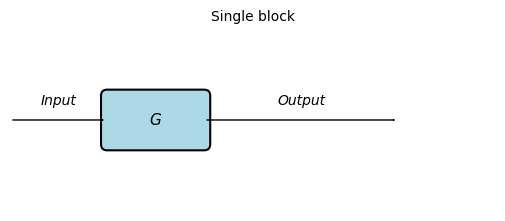

In [4]:
fig, ax = plt.subplots(figsize=(6, 2.3))
setup_axes(ax, (0, 4), (0, 1.5))
b = Block(1.2, 0.75, '$G$')
draw_block_obj(ax, b)
draw_connection(ax, (0, 0.75), b.center_left, 'Input')
draw_connection(ax, b.center_right, (3.2, 0.75), 'Output')
ax.set_title('Single block', fontsize=10)
fig.tight_layout()
plt.show()

### Open-loop control

Recall the **block on ice** from the introduction. We can draw its control system as a block diagram.

The controller does **not** see the actual position. This is open-loop.


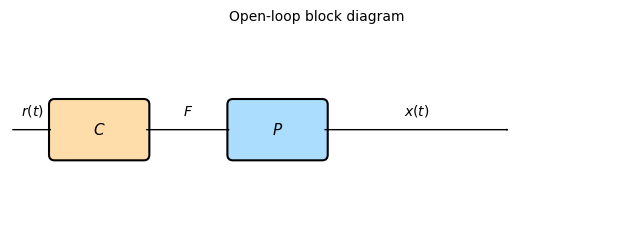

In [5]:
fig, ax = plt.subplots(figsize=(8, 2.5))
setup_axes(ax, (0, 5.5), (0, 1.8))
c = Block(0.8, 0.9, '$C$', w=0.8, h=0.45, facecolor='#FFDDAA')
p = Block(2.4, 0.9, '$P$', w=0.8, h=0.45, facecolor='#AADDFF')
draw_block_obj(ax, c)
draw_block_obj(ax, p)
draw_connection(ax, (0, 0.9), c.center_left, '$r(t)$')
draw_connection(ax, c.center_right, p.center_left, '$F$')
draw_connection(ax, p.center_right, (4.5, 0.9), '$x(t)$')
ax.set_title('Open-loop block diagram', fontsize=10)
fig.tight_layout()
plt.show()

### Closed-loop (feedback) control

Now the **sensor** measures the position and feeds it back. The **summing junction** compares the setpoint $r(t)$ with the measured position to produce the **error** $e(t)$, which is routed to the **controller**, meaning the controller can now produce an output based on an observation about the system.


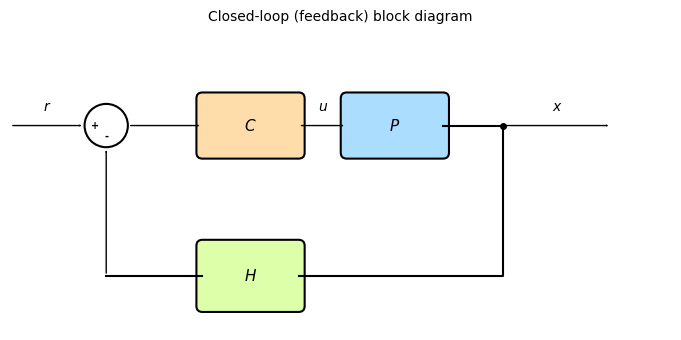

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
setup_axes(ax, (0, 5.5), (0, 2.5))
s = Summer(0.8, 1.7, left='+', bottom='-')
c = Block(2.0, 1.7, '$C$', w=0.8, h=0.45, facecolor='#FFDDAA')
p = Block(3.2, 1.7, '$P$', w=0.8, h=0.45, facecolor='#AADDFF')
h = Block(2.0, 0.45, '$H$', w=0.8, h=0.5, facecolor='#DDFFAA')
draw_summing_obj(ax, s)
draw_block_obj(ax, c)
draw_block_obj(ax, p)
draw_block_obj(ax, h)
draw_connection(ax, (0, 1.7), s.entry_left, '$r$')
draw_connection(ax, s.exit, c.center_left)
draw_connection(ax, c.center_right, p.center_left, '$u$')
jx = p.right + 0.5
draw_line(ax, [p.center_right, (jx, 1.7)])
draw_connection(ax, (jx, 1.7), (5.0, 1.7), '$x$')
draw_dot(ax, (jx, 1.7))
draw_line(ax, [(jx, 1.7), (jx, 0.45), h.center_right])
draw_line(ax, [h.center_left, (s.x, 0.45)])
draw_connection(ax, (s.x, 0.45), s.entry_bottom)
ax.set_title('Closed-loop (feedback) block diagram', fontsize=10)
fig.tight_layout()
plt.show()

---

## Summary

- **Block diagrams** are the visual language of control systems. They show how signals flow through a system.
- **Basic elements**: blocks (transfer functions), summing junctions ($\Sigma$), take-off points, and arrows.
- **Open-loop** diagrams have no feedback path; **closed-loop** diagrams feed the output back for comparison.